In [1]:
pip install --upgrade --force-reinstall nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached regex-2025.9.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Using cached regex-2025.9.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
Using cached click-8.2.1-py3-none-any.whl (102 kB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
  Attempting uninstall: regex
    Found existing installation: regex 2025.9.1
    Uninstalling regex-2025.9.1:
      Successfully uninstalled regex-2025.9.1


Original Data:
                                                text
0  The new movie is absolutely amazing! 🎬 A must-...
1  I'm so disappointed with the service. This is ...
2         Just got my new phone. It's okay, I guess.
3          What a beautiful day! The sun is shining.
4           Ugh, traffic is a nightmare right now 😫.
5          The product arrived broken. I'm so angry.
6      Just finished a great book. Highly recommend!
7       Feeling pretty neutral about the new policy.
8         This song is fire 🔥! Can't stop listening.
9    The new update broke the app. Very frustrating.
--------------------------------------------------
Cleaned Data:
                                                text  \
0  The new movie is absolutely amazing! 🎬 A must-...   
1  I'm so disappointed with the service. This is ...   
2         Just got my new phone. It's okay, I guess.   
3          What a beautiful day! The sun is shining.   
4           Ugh, traffic is a nightmare right now 😫.   
5

/tmp/ipython-input-763339163.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


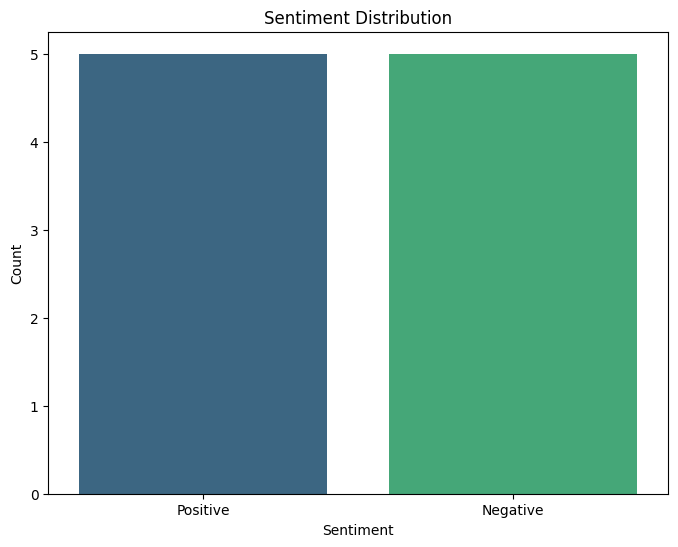

/tmp/ipython-input-763339163.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y='compound_score', data=df, palette='plasma')


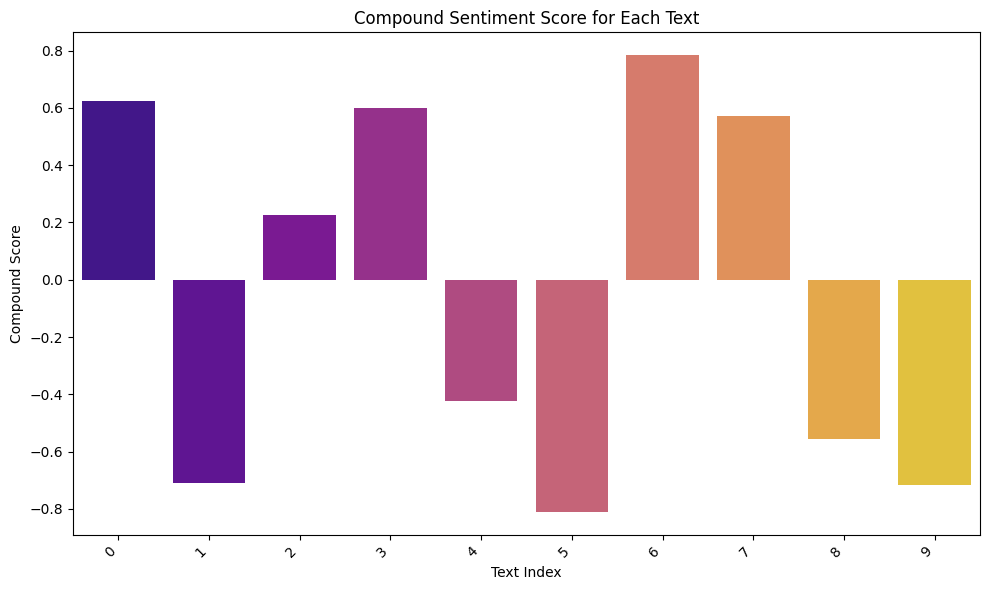


Final Sentiment Counts:
sentiment
Positive    5
Negative    5
Name: count, dtype: int64


In [9]:
import pandas as pd
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'text': [
        "The new movie is absolutely amazing! 🎬 A must-watch.",
        "I'm so disappointed with the service. This is ridiculous.",
        "Just got my new phone. It's okay, I guess.",
        "What a beautiful day! The sun is shining.",
        "Ugh, traffic is a nightmare right now 😫.",
        "The product arrived broken. I'm so angry.",
        "Just finished a great book. Highly recommend!",
        "Feeling pretty neutral about the new policy.",
        "This song is fire 🔥! Can't stop listening.",
        "The new update broke the app. Very frustrating."
    ]
}
df = pd.DataFrame(data)

print("Original Data:")
print(df)
print("-" * 50)


def clean_text(text):
    text = text.lower()
    text = re.sub(r'@[^\s]+', ' ', text)
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_text'] = df['text'].apply(clean_text)

print("Cleaned Data:")
print(df[['text', 'cleaned_text']])
print("-" * 50)


sid = SentimentIntensityAnalyzer()

df['scores'] = df['cleaned_text'].apply(lambda text: sid.polarity_scores(text))

df['compound_score'] = df['scores'].apply(lambda score: score['compound'])

df['sentiment'] = df['compound_score'].apply(
    lambda s: 'Positive' if s >= 0.05 else ('Negative' if s <= -0.05 else 'Neutral')
)

print("Sentiment Analysis Results:")
print(df[['text', 'compound_score', 'sentiment']])
print("-" * 50)

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df.index, y='compound_score', data=df, palette='plasma')
plt.title('Compound Sentiment Score for Each Text')
plt.xlabel('Text Index')
plt.ylabel('Compound Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sentiment_counts = df['sentiment'].value_counts()
print("\nFinal Sentiment Counts:")
print(sentiment_counts)